# 11 - Build CJEU → CJEU Network & First Analysis

This notebook builds a directed homogeneous citation network between CJEU cases,
and performs a focused first analysis using the most interpretable metrics for a same-layer citation network.

**Input:** `data/processed/cjeu_cjeu_case_matches.csv`

**Output:**
- `data/processed/network/cjeu_cjeu_nodes.csv`
- `data/processed/network/cjeu_cjeu_edges.csv`
- `data/processed/network/cjeu_cjeu_network.graphml`
- `data/processed/network/cjeu_cjeu_node_metrics.csv`

## 1. Imports and Configuration

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("data/processed")
INPUT_PATH = DATA_DIR / "cjeu_cjeu_case_matches.csv"

OUT_DIR           = DATA_DIR / "network" / "cjeu_cjeu"
NODES_PATH        = OUT_DIR / "cjeu_cjeu_nodes.csv"
EDGES_PATH        = OUT_DIR / "cjeu_cjeu_edges.csv"
GRAPHML_PATH      = OUT_DIR / "cjeu_cjeu_network.graphml"
NODE_METRICS_PATH = OUT_DIR / "cjeu_cjeu_node_metrics.csv"

print("Configuration loaded.")

Configuration loaded.


## 2. Load CSV

In [2]:
df = pd.read_csv(INPUT_PATH, dtype=str).fillna("")

print(f"Rows loaded : {len(df):,}")
print(f"Columns     : {list(df.columns)}")
df.head(3)

Rows loaded : 6,763
Columns     : ['source_celex_id', 'source_cellar_id', 'source_case_number', 'source_title', 'source_document_date', 'target_celex_id', 'target_cellar_id', 'target_case_number', 'target_title', 'matched_text', 'normalized_match', 'citation_style', 'is_old_case_citation', 'match_context', 'document_source_url', 'document_format', 'processing_status']


,source_celex_id,source_cellar_id,source_case_number,source_title,source_document_date,target_celex_id,target_cellar_id,target_case_number,target_title,matched_text,normalized_match,citation_style,is_old_case_citation,match_context,document_source_url,document_format,processing_status
0,61994CJ0068,ba1070bd-c40d-4171-88df-8578a05e9d17,C-68/94,,1998-03-31,61962CJ0025,f5ba5b50-6d82-4ebe-8d33-37edcfbec191,,,25/62,25/62,old_unprefixed,True,"view, neither SCPA nor EMC is directly and in...",https://publications.europa.eu/resource/celex/...,html_eng,matched
1,61994CJ0068,ba1070bd-c40d-4171-88df-8578a05e9d17,C-68/94,,1998-03-31,61984CJ0169,14ed8ce6-71b4-43a4-ad7e-a49464e22696,,,169/84,169/84,old_unprefixed,True,"ngs before the Commission, and thus cannot be ...",https://publications.europa.eu/resource/celex/...,html_eng,matched
2,61994CJ0068,ba1070bd-c40d-4171-88df-8578a05e9d17,C-68/94,,1998-03-31,61981CJ0135,1f789639-f1a9-494b-ad14-05fbb563a05b,,,135/81,135/81,old_unprefixed,True,"g to the case-law, is not sufficient reason to...",https://publications.europa.eu/resource/celex/...,html_eng,matched


## 3. Filter: Only Valid Matches

In [3]:
matched = df[df["processing_status"].str.strip() == "matched"].copy()

# Drop rows with missing source or target celex ids
matched = matched[
    matched["source_celex_id"].str.strip().ne("") &
    matched["target_celex_id"].str.strip().ne("")
].copy()

# Remove self-citations
matched = matched[
    matched["source_celex_id"].str.strip() != matched["target_celex_id"].str.strip()
].copy()

print(f"Rows after filtering: {len(matched):,}")
print(f"Unique processing_status values: {matched['processing_status'].unique()}")

Rows after filtering: 6,763
Unique processing_status values: <StringArray>
['matched']
Length: 1, dtype: str


## 4. Deduplicate to One Edge per Source-Target Pair

Each raw row represents one pattern match. Multiple rows may exist for the same
source-target pair. We aggregate them into one unique directed edge per
`(source_celex_id, target_celex_id)` pair, keeping useful aggregated attributes.

In [4]:
edges_raw = (
    matched
    .groupby(["source_celex_id", "target_celex_id"], sort=False)
    .agg(
        source_case_number    = ("source_case_number", "first"),
        target_case_number    = ("target_case_number", "first"),
        match_count           = ("citation_style", "count"),
        citation_styles       = ("citation_style", lambda s: "|".join(s.unique())),
        example_match_context = ("match_context", "first"),
    )
    .reset_index()
)

print(f"Unique CJEU-CJEU pairs (edges): {len(edges_raw):,}")
edges_raw.head(3)

Unique CJEU-CJEU pairs (edges): 6,760


,source_celex_id,target_celex_id,source_case_number,target_case_number,match_count,citation_styles,example_match_context
0,61994CJ0068,61962CJ0025,C-68/94,,1,old_unprefixed,"view, neither SCPA nor EMC is directly and in..."
1,61994CJ0068,61984CJ0169,C-68/94,,1,old_unprefixed,"ngs before the Commission, and thus cannot be ..."
2,61994CJ0068,61981CJ0135,C-68/94,,1,old_unprefixed,"g to the case-law, is not sufficient reason to..."


## 5. Build Node Table

All CJEU cases that appear as source or target are collected into a single node table.
Source and target metadata are merged carefully so each case appears only once.

In [5]:
# ── Source node metadata ───────────────────────────────────────────────────────
src_meta = (
    matched[["source_celex_id", "source_cellar_id", "source_case_number",
             "source_title", "source_document_date"]]
    .drop_duplicates(subset="source_celex_id")
    .rename(columns={
        "source_celex_id"      : "celex_id",
        "source_cellar_id"     : "cellar_id",
        "source_case_number"   : "case_number",
        "source_title"         : "label",
        "source_document_date" : "date",
    })
    .copy()
)

# ── Target node metadata ───────────────────────────────────────────────────────
tgt_meta = (
    matched[["target_celex_id", "target_cellar_id", "target_case_number", "target_title"]]
    .drop_duplicates(subset="target_celex_id")
    .rename(columns={
        "target_celex_id"    : "celex_id",
        "target_cellar_id"   : "cellar_id",
        "target_case_number" : "case_number",
        "target_title"       : "label",
    })
    .copy()
)
tgt_meta["date"] = ""

# ── Merge: source metadata takes priority ─────────────────────────────────────
all_meta = pd.concat([src_meta, tgt_meta], ignore_index=True)
all_meta = all_meta.drop_duplicates(subset="celex_id", keep="first")

cjeu_nodes = pd.DataFrame({
    "node_id"    : "cjeu:" + all_meta["celex_id"],
    "node_type"  : "cjeu",
    "label"      : all_meta["label"].values,
    "celex_id"   : all_meta["celex_id"].values,
    "cellar_id"  : all_meta["cellar_id"].values,
    "case_number": all_meta["case_number"].values,
    "date"       : all_meta["date"].values,
})

print(f"CJEU nodes: {len(cjeu_nodes):,}")
cjeu_nodes.head(3)

CJEU nodes: 2,000


,node_id,node_type,label,celex_id,cellar_id,case_number,date
0,cjeu:61994CJ0068,cjeu,,61994CJ0068,ba1070bd-c40d-4171-88df-8578a05e9d17,C-68/94,1998-03-31
1,cjeu:61999TJ0219,cjeu,,61999TJ0219,c771ddef-393a-48fb-9fbd-a07f18f4b592,T-219/99,2003-12-17
2,cjeu:62002TJ0038,cjeu,,62002TJ0038,b6ccae39-9aa5-4253-953a-22b37892e1ff,T-38/02,2005-10-25


## 6. Build Edge Table

In [6]:
edges = edges_raw.copy()
edges.insert(0, "source", "cjeu:" + edges["source_celex_id"])
edges.insert(1, "target", "cjeu:" + edges["target_celex_id"])

print(f"Edges: {len(edges):,}")
edges.head(3)

Edges: 6,760


,source,target,source_celex_id,target_celex_id,source_case_number,target_case_number,match_count,citation_styles,example_match_context
0,cjeu:61994CJ0068,cjeu:61962CJ0025,61994CJ0068,61962CJ0025,C-68/94,,1,old_unprefixed,"view, neither SCPA nor EMC is directly and in..."
1,cjeu:61994CJ0068,cjeu:61984CJ0169,61994CJ0068,61984CJ0169,C-68/94,,1,old_unprefixed,"ngs before the Commission, and thus cannot be ..."
2,cjeu:61994CJ0068,cjeu:61981CJ0135,61994CJ0068,61981CJ0135,C-68/94,,1,old_unprefixed,"g to the case-law, is not sufficient reason to..."


## 7. Build NetworkX Directed Graph

In [7]:
G = nx.DiGraph()

for _, row in cjeu_nodes.iterrows():
    G.add_node(
        row["node_id"],
        node_type="cjeu",
        label=row["label"],
        celex_id=row["celex_id"],
        cellar_id=row["cellar_id"],
        case_number=row["case_number"],
        date=row["date"],
    )

for _, row in edges.iterrows():
    G.add_edge(
        row["source"],
        row["target"],
        match_count=int(row["match_count"]),
        citation_styles=row["citation_styles"],
        example_match_context=str(row["example_match_context"])[:300],
    )

print(f"Graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Graph: 2,000 nodes, 6,760 edges


## 8. Basic Statistics

In [8]:
print(f"CJEU nodes : {len(cjeu_nodes):,}")
print(f"Edges      : {len(edges):,}")
print(f"Is directed: {G.is_directed()}")

CJEU nodes : 2,000
Edges      : 6,760
Is directed: True


---
## 9. Citation Style Distribution

A quick look at how many matches come from each citation style (`modern_prefixed` vs `old_unprefixed`).
This is a descriptive note, not a major analysis section.

In [9]:
style_counts = matched["citation_style"].value_counts().reset_index()
style_counts.columns = ["citation_style", "match_count"]

print("Citation style distribution (raw match rows):")
display(style_counts)

Citation style distribution (raw match rows):


,citation_style,match_count
0,old_unprefixed,5246
1,modern_prefixed,1517


---
## 10. Network Structure Metrics

The sections below compute three structural properties of the CJEU → CJEU citation graph:
**reciprocity**, **weakly connected components**, and **strongly connected components**.

### 10.1 Reciprocity

**What it measures:**
Reciprocity is the fraction of edges that are mutual — if case A cites case B, does case B also cite case A?
A value of 0 means no mutual citations; 1 means every citation is reciprocated.

**Why it matters:**
In a legal citation network, high reciprocity would be unusual (decisions typically cite earlier cases).
Low reciprocity confirms the expected temporal, hierarchical structure of case law.

In [10]:
recip = nx.reciprocity(G)
print(f"Network reciprocity: {recip:.4f}")
print(f"({recip*100:.2f}% of edges are mutual citations)")

Network reciprocity: 0.0417
(4.17% of edges are mutual citations)


### 10.2 Weakly Connected Components

**What it measures:**
A weakly connected component (WCC) is a maximal set of nodes reachable from each other
if edge directions are ignored. A large dominant WCC means most CJEU cases are structurally
linked through the citation graph.

**Why it matters:**
WCCs reveal whether the network forms one large connected cluster or splits into isolated sub-networks.
Small isolated components may indicate peripheral citation clusters.

In [11]:
wccs = list(nx.weakly_connected_components(G))
wccs_sorted = sorted(wccs, key=len, reverse=True)

print(f"Number of weakly connected components : {len(wccs_sorted):,}")
print(f"Largest WCC size                       : {len(wccs_sorted[0]):,} nodes")
print(f"Nodes in largest WCC (% of total)      : {len(wccs_sorted[0]) / G.number_of_nodes() * 100:.1f}%")

wcc_summary = pd.DataFrame({
    "component_id": range(1, len(wccs_sorted) + 1),
    "size"        : [len(c) for c in wccs_sorted],
})

print("\nWeakly connected component sizes (top 20):")
display(wcc_summary.head(20))

Number of weakly connected components : 32
Largest WCC size                       : 1,919 nodes
Nodes in largest WCC (% of total)      : 96.0%

Weakly connected component sizes (top 20):


,component_id,size
0,1,1919
1,2,6
2,3,6
3,4,4
4,5,4
5,6,4
6,7,3
7,8,3
8,9,3
9,10,3


### 10.3 Strongly Connected Components

**What it measures:**
A strongly connected component (SCC) is a maximal set of nodes where every node can reach
every other node following directed edges. In a citation network, large SCCs indicate
cycles of mutual citation.

**Why it matters:**
Most legal citation networks are nearly acyclic (older cases cannot cite newer ones),
so most SCCs will be trivial (size 1). A non-trivial SCC indicates mutual or circular citation patterns.

In [12]:
sccs = list(nx.strongly_connected_components(G))
sccs_sorted = sorted(sccs, key=len, reverse=True)

print(f"Number of strongly connected components : {len(sccs_sorted):,}")
print(f"Largest SCC size                         : {len(sccs_sorted[0]):,} nodes")
print(f"Nodes in largest SCC (% of total)        : {len(sccs_sorted[0]) / G.number_of_nodes() * 100:.1f}%")

scc_summary = pd.DataFrame({
    "component_id": range(1, len(sccs_sorted) + 1),
    "size"        : [len(c) for c in sccs_sorted],
})

print("\nStrongly connected component sizes (top 20):")
display(scc_summary.head(20))

Number of strongly connected components : 1,942
Largest SCC size                         : 14 nodes
Nodes in largest SCC (% of total)        : 0.7%

Strongly connected component sizes (top 20):


,component_id,size
0,1,14
1,2,8
2,3,5
3,4,3
4,5,3
5,6,3
6,7,3
7,8,3
8,9,3
9,10,3


---
## 11. Visualisation (Top 50 Nodes)

A quick visual impression using the 25 most-cited and 25 most-citing CJEU cases.
Nodes are coloured by role: orange = highly cited, blue = highly citing, green = both.

Subgraph: 50 nodes, 251 edges


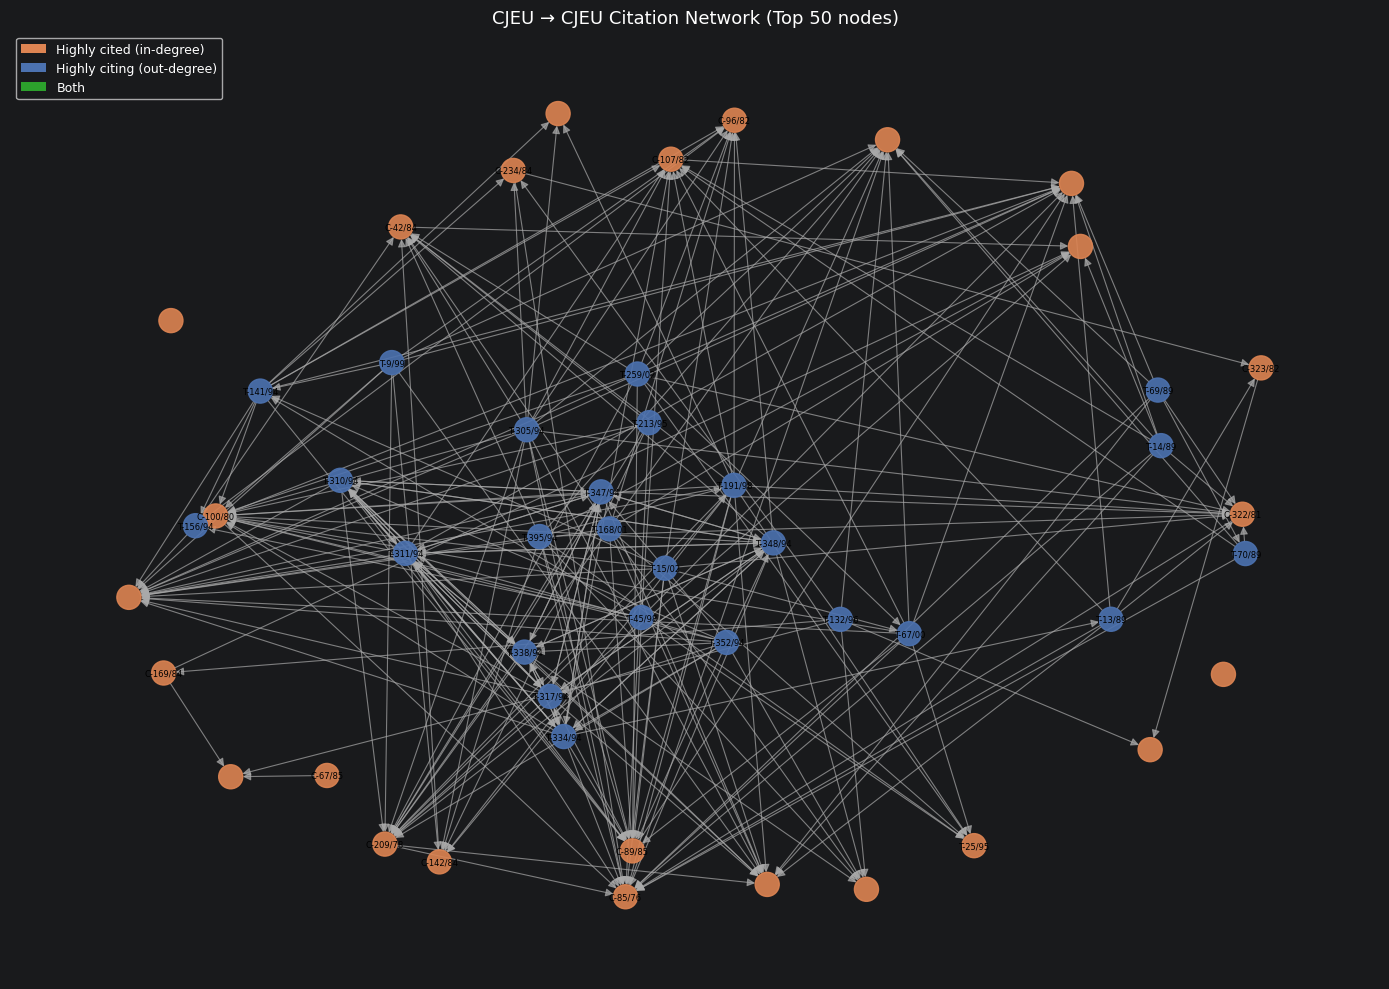

In [13]:
from matplotlib.patches import Patch

in_deg_series  = pd.Series(dict(G.in_degree()),  name="in_degree").sort_values(ascending=False)
out_deg_series = pd.Series(dict(G.out_degree()), name="out_degree").sort_values(ascending=False)

top_cited_ids  = in_deg_series.head(25).index.tolist()
top_citing_ids = out_deg_series.head(25).index.tolist()

sub_nodes = set(top_cited_ids) | set(top_citing_ids)
H = G.subgraph(sub_nodes).copy()

print(f"Subgraph: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")

color_map = []
for n in H.nodes():
    in_top  = n in top_cited_ids
    out_top = n in top_citing_ids
    if in_top and out_top:
        color_map.append("#2ca02c")
    elif in_top:
        color_map.append("#DD8452")
    else:
        color_map.append("#4C72B0")

labels = {n: H.nodes[n].get("case_number", n) for n in H.nodes()}

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(H, seed=42, k=1.5)

nx.draw_networkx_nodes(H, pos, node_color=color_map, node_size=300, alpha=0.9, ax=ax)
nx.draw_networkx_edges(H, pos, edge_color="#aaaaaa", arrows=True,
                       arrowsize=12, width=0.8, alpha=0.7, ax=ax)
nx.draw_networkx_labels(H, pos, labels=labels, font_size=6, ax=ax)

legend_elements = [
    Patch(facecolor="#DD8452", label="Highly cited (in-degree)"),
    Patch(facecolor="#4C72B0", label="Highly citing (out-degree)"),
    Patch(facecolor="#2ca02c", label="Both"),
]
ax.legend(handles=legend_elements, loc="upper left", fontsize=9)
ax.set_title("CJEU → CJEU Citation Network (Top 50 nodes)", fontsize=13)
ax.axis("off")
plt.tight_layout()
plt.show()

---
## 12. Network Analysis

The sections below compute the core node metrics for this directed CJEU citation graph.
Because this is a same-layer network, all standard directed-graph metrics are meaningful:
**in-degree**, **out-degree**, **PageRank**, **HITS**, and **betweenness centrality**.

### 12.1 In-Degree and Out-Degree

**What it measures:**
- **In-degree** = number of incoming edges → how often a CJEU case is *cited by other CJEU cases*.
- **Out-degree** = number of outgoing edges → how many other CJEU cases a document *cites*.

**Why it matters:**
In-degree is the most direct measure of a case's influence within the CJEU corpus.
Out-degree reveals which CJEU documents draw most heavily on prior CJEU precedents.

**Most meaningful for:** both metrics apply equally to all CJEU nodes.

In [14]:
in_degree_all  = dict(G.in_degree())
out_degree_all = dict(G.out_degree())

cjeu_in = (
    cjeu_nodes.set_index("node_id")[["case_number", "label", "date"]]
    .assign(in_degree=lambda df: df.index.map(in_degree_all))
    .sort_values("in_degree", ascending=False)
)

print("Top 20 most cited CJEU cases (in-degree):")
display(cjeu_in.head(20))

Top 20 most cited CJEU cases (in-degree):


,case_number,label,date,in_degree
node_id,,,,
cjeu:61980CJ0100,C-100/80,,1983-06-07,116
cjeu:61976CJ0085,C-85/76,,1979-02-13,112
cjeu:61962CJ0025,,,,108
cjeu:61981CJ0322,C-322/81,,1983-11-09,98
cjeu:61973CJ0040,,,,94
cjeu:61981CJ0060,,,,81
cjeu:61982CJ0107,C-107/82,,1983-10-25,81
cjeu:61969CJ0041,,,,78
cjeu:61969CJ0048,,,,71


In [15]:
cjeu_out = (
    cjeu_nodes.set_index("node_id")[["case_number", "label", "date"]]
    .assign(out_degree=lambda df: df.index.map(out_degree_all))
    .sort_values("out_degree", ascending=False)
)

print("Top 20 most citing CJEU cases (out-degree):")
display(cjeu_out.head(20))

Top 20 most citing CJEU cases (out-degree):


,case_number,label,date,out_degree
node_id,,,,
cjeu:61994TJ0305,T-305/94,,1999-04-20,56
cjeu:61994TJ0141,T-141/94,,1999-03-11,42
cjeu:61998TJ0191,T-191/98,,2003-09-30,32
cjeu:61994TJ0348,T-348/94,,1998-05-14,31
cjeu:61994TJ0347,T-347/94,,1998-05-14,29
cjeu:61998TJ0045,T-45/98,,2001-12-13,28
cjeu:61989TJ0069,T-69/89,,1991-07-10,27
cjeu:61995TJ0213,T-213/95,,1997-10-22,26
cjeu:61994TJ0352,T-352/94,,1998-05-14,25


### 12.2 PageRank

**What it measures:**
PageRank assigns a prestige score to each node based on the number and quality of incoming links.
A node receives a higher score if it is cited by nodes that are themselves highly cited.

**Why it matters:**
Unlike raw in-degree, PageRank accounts for the *importance* of the citing document.
A CJEU case cited by many influential CJEU judgments will rank higher than one cited
by less prominent cases. This identifies the most foundational CJEU precedents.

**Most meaningful for:** all CJEU nodes — identifies the most *prestigious* cases in the network.

In [16]:
pagerank = nx.pagerank(G, alpha=0.85)

cjeu_pr = (
    cjeu_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        in_degree=lambda df: df.index.map(in_degree_all),
        pagerank =lambda df: df.index.map(pagerank),
    )
    .sort_values("pagerank", ascending=False)
)

print("Top 20 CJEU cases by PageRank:")
display(cjeu_pr.head(20))

Top 20 CJEU cases by PageRank:


,case_number,label,in_degree,pagerank
node_id,,,,
cjeu:61976CJ0085,C-85/76,,112,0.011569
cjeu:61962CJ0025,,,108,0.010098
cjeu:61979CJ0730,,,61,0.009802
cjeu:61981CJ0060,,,81,0.009007
cjeu:61957CJ0002,,,18,0.008689
cjeu:61976CJ0026,,,53,0.008652
cjeu:61969CJ0048,,,71,0.008335
cjeu:61974CJ0094,,,9,0.007948
cjeu:61965CJ0056,C-56/65,,44,0.007261


### 12.3 HITS (Hubs and Authorities)

**What it measures:**
HITS computes two scores per node:
- **Hub score**: how well a node points to good authorities (high out-degree to important cases).
- **Authority score**: how well a node is pointed to by good hubs (cited by important citing cases).

**Why it matters:**
In a CJEU citation network, authority score identifies the most foundational precedents,
while hub score identifies the cases that most systematically reference key precedents.
This complements PageRank by separating the *cited* role from the *citing* role.

**Most meaningful for:** both roles are relevant in a same-layer citation network.

In [17]:
hits_hub, hits_authority = nx.hits(G, max_iter=500)

cjeu_hits_auth = (
    cjeu_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        in_degree =lambda df: df.index.map(in_degree_all),
        authority =lambda df: df.index.map(hits_authority),
        hub       =lambda df: df.index.map(hits_hub),
    )
    .sort_values("authority", ascending=False)
)

print("Top 20 CJEU cases by HITS authority score:")
display(cjeu_hits_auth.head(20))

Top 20 CJEU cases by HITS authority score:


,case_number,label,in_degree,authority,hub
node_id,,,,,
cjeu:61980CJ0100,C-100/80,,116,0.034574,0.000835
cjeu:61973CJ0040,,,94,0.030384,-0.000000
cjeu:61976CJ0085,C-85/76,,112,0.024656,0.000563
cjeu:61981CJ0322,C-322/81,,98,0.024591,0.000692
cjeu:61969CJ0041,,,78,0.023235,-0.000000
cjeu:61982CJ0107,C-107/82,,81,0.020131,0.000707
cjeu:61985CJ0089,C-89/85,,67,0.019997,0.000503
cjeu:61969CJ0048,,,71,0.019550,-0.000000
cjeu:61978CJ0209,C-209/78,,58,0.018243,0.001625


### 12.4 Betweenness Centrality

**What it measures:**
Betweenness centrality counts how often a node lies on the shortest path between two other nodes.
A node with high betweenness acts as a *bridge* or *connector* within the network.

**Why it matters:**
In the CJEU citation network, a case with high betweenness is not just frequently cited —
it structurally connects otherwise separate clusters of CJEU decisions.
Such cases may represent pivotal precedents that link different areas of CJEU case law.

**Important note:** Betweenness is a supplementary structural metric.
In-degree and PageRank remain the primary indicators of importance.

In [18]:
betweenness = nx.betweenness_centrality(G, normalized=True)

cjeu_bw = (
    cjeu_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        in_degree   =lambda df: df.index.map(in_degree_all),
        betweenness =lambda df: df.index.map(betweenness),
    )
    .sort_values("betweenness", ascending=False)
)

print("Top 20 CJEU cases by betweenness centrality:")
display(cjeu_bw.head(20))

Top 20 CJEU cases by betweenness centrality:


,case_number,label,in_degree,betweenness
node_id,,,,
cjeu:61989TJ0068,T-68/89,,23,0.001610
cjeu:61989TJ0069,T-69/89,,4,0.001053
cjeu:61981CJ0322,C-322/81,,98,0.000993
cjeu:61980CJ0031,C-31/80,,20,0.000917
cjeu:61998TJ0191,T-191/98,,18,0.000901
cjeu:61994TJ0374,T-374/94,,31,0.000659
cjeu:61994TJ0141,T-141/94,,13,0.000574
cjeu:61994TJ0305,T-305/94,,8,0.000544
cjeu:61989TJ0079,T-79/89,,33,0.000475


---
## 13. Node-Level Metric Summary Table

All core metrics are combined into a single node-level table for easy inspection and export.
Each row represents one CJEU node with all computed metrics.

In [19]:
node_metrics = cjeu_nodes[["node_id", "label", "case_number", "date"]].copy()

node_metrics["in_degree"]      = node_metrics["node_id"].map(in_degree_all)
node_metrics["out_degree"]     = node_metrics["node_id"].map(out_degree_all)
node_metrics["pagerank"]       = node_metrics["node_id"].map(pagerank)
node_metrics["hits_hub"]       = node_metrics["node_id"].map(hits_hub)
node_metrics["hits_authority"] = node_metrics["node_id"].map(hits_authority)
node_metrics["betweenness"]    = node_metrics["node_id"].map(betweenness)

print(f"Node metrics table: {len(node_metrics):,} rows")
display(node_metrics.sort_values("in_degree", ascending=False).head(20))

Node metrics table: 2,000 rows


,node_id,label,case_number,date,in_degree,out_degree,pagerank,hits_hub,hits_authority,betweenness
498,cjeu:61980CJ0100,,C-100/80,1983-06-07,116,4,0.004322,0.000835,0.034574,0.000227
30,cjeu:61976CJ0085,,C-85/76,1979-02-13,112,2,0.011569,0.000563,0.024656,0.000240
1680,cjeu:61962CJ0025,,,,108,0,0.010098,-0.000000,0.002328,0.000000
38,cjeu:61981CJ0322,,C-322/81,1983-11-09,98,2,0.005035,0.000692,0.024591,0.000993
1697,cjeu:61973CJ0040,,,,94,0,0.003547,-0.000000,0.030384,0.000000
1686,cjeu:61981CJ0060,,,,81,0,0.009007,-0.000000,0.005817,0.000000
755,cjeu:61982CJ0107,,C-107/82,1983-10-25,81,2,0.004212,0.000707,0.020131,0.000167
1710,cjeu:61969CJ0041,,,,78,0,0.002920,-0.000000,0.023235,0.000000
1779,cjeu:61969CJ0048,,,,71,0,0.008335,-0.000000,0.019550,0.000000
359,cjeu:61985CJ0089,,C-89/85,1988-09-27,67,1,0.002375,0.000503,0.019997,0.000010


---
## 14. Summary Tables

### 14A. Top Cited CJEU Cases

Ranked by **in-degree** (raw citation count), also showing **PageRank** and **HITS authority**.
These are the CJEU cases most frequently referenced by other CJEU documents.

In [20]:
top_cited = (
    cjeu_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        in_degree =lambda df: df.index.map(in_degree_all),
        pagerank  =lambda df: df.index.map(pagerank),
        authority =lambda df: df.index.map(hits_authority),
    )
    .sort_values(["in_degree", "pagerank"], ascending=False)
    .reset_index(drop=True)
)

print("Top 30 most cited CJEU cases (ranked by in-degree, then PageRank):")
display(top_cited.head(30))

Top 30 most cited CJEU cases (ranked by in-degree, then PageRank):


,case_number,label,in_degree,pagerank,authority
0,C-100/80,,116,0.004322,0.034574
1,C-85/76,,112,0.011569,0.024656
2,,,108,0.010098,0.002328
3,C-322/81,,98,0.005035,0.024591
4,,,94,0.003547,0.030384
5,,,81,0.009007,0.005817
6,C-107/82,,81,0.004212,0.020131
7,,,78,0.002920,0.023235
8,,,71,0.008335,0.019550
9,C-89/85,,67,0.002375,0.019997


### 14B. Top Citing CJEU Cases

Ranked by **out-degree** (number of distinct CJEU cases cited), also showing **HITS hub score**.
These are the CJEU documents that draw most heavily on prior CJEU precedents.

In [21]:
top_citing = (
    cjeu_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        out_degree=lambda df: df.index.map(out_degree_all),
        hub       =lambda df: df.index.map(hits_hub),
    )
    .sort_values("out_degree", ascending=False)
    .reset_index(drop=True)
)

print("Top 30 most citing CJEU cases (ranked by out-degree):")
display(top_citing.head(30))

Top 30 most citing CJEU cases (ranked by out-degree):


,case_number,label,out_degree,hub
0,T-305/94,,56,0.011606
1,T-141/94,,42,0.006629
2,T-191/98,,32,0.009833
3,T-348/94,,31,0.008315
4,T-347/94,,29,0.008617
5,T-45/98,,28,0.004701
6,T-69/89,,27,0.003722
7,T-213/95,,26,0.006138
8,T-352/94,,25,0.007786
9,T-15/02,,24,0.006756


### 14C. Top Bridge Cases by Betweenness

Ranked by **betweenness centrality** — these are the CJEU cases that act as structural bridges
within the citation network, connecting otherwise separate clusters of decisions.

In [22]:
top_bridges = (
    cjeu_nodes.set_index("node_id")[["case_number", "label"]]
    .assign(
        betweenness=lambda df: df.index.map(betweenness),
        in_degree  =lambda df: df.index.map(in_degree_all),
        pagerank   =lambda df: df.index.map(pagerank),
    )
    .sort_values("betweenness", ascending=False)
    .reset_index(drop=True)
)

print("Top 20 CJEU bridge cases by betweenness centrality:")
display(top_bridges.head(20))

Top 20 CJEU bridge cases by betweenness centrality:


,case_number,label,betweenness,in_degree,pagerank
0,T-68/89,,0.001610,23,0.000788
1,T-69/89,,0.001053,4,0.000585
2,C-322/81,,0.000993,98,0.005035
3,C-31/80,,0.000917,20,0.003432
4,T-191/98,,0.000901,18,0.000877
5,T-374/94,,0.000659,31,0.001538
6,T-141/94,,0.000574,13,0.000416
7,T-305/94,,0.000544,8,0.000627
8,T-79/89,,0.000475,33,0.002103
9,T-156/94,,0.000435,3,0.000255


---
## 15. Export

In [23]:
OUT_DIR.mkdir(parents=True, exist_ok=True)

cjeu_nodes.to_csv(NODES_PATH, index=False, encoding="utf-8")
print(f"Saved {len(cjeu_nodes):,} nodes to: {NODES_PATH}")

edges.to_csv(EDGES_PATH, index=False, encoding="utf-8")
print(f"Saved {len(edges):,} edges to: {EDGES_PATH}")

nx.write_graphml(G, str(GRAPHML_PATH))
print(f"Saved GraphML to: {GRAPHML_PATH}")

node_metrics.to_csv(NODE_METRICS_PATH, index=False, encoding="utf-8")
print(f"Saved node metrics to: {NODE_METRICS_PATH}")


Saved 2,000 nodes to: data\processed\network\cjeu_cjeu\cjeu_cjeu_nodes.csv
Saved 6,760 edges to: data\processed\network\cjeu_cjeu\cjeu_cjeu_edges.csv
Saved GraphML to: data\processed\network\cjeu_cjeu\cjeu_cjeu_network.graphml
Saved node metrics to: data\processed\network\cjeu_cjeu\cjeu_cjeu_node_metrics.csv
